# roomsplat — Office Tour: Experiments & Learnings

This notebook documents every training run performed on a single office scene, the decisions made,
the failures encountered, and the lessons learned about making 3D Gaussian Splatting work on
real indoor phone video.

The **roomsplat pipeline and viewer** are open source: [github.com/Ahmedn1/roomsplat](https://github.com/Ahmedn1/roomsplat)  
An interactive live demo of the final scene is at [roomsplat-demo.netlify.app](https://roomsplat-demo.netlify.app).

**Scene**: An office room, phone video recorded in 8K portrait (4320 × 7680), 5.5 GB  
**Hardware**: NVIDIA RTX 3080 16 GB, Ubuntu 22.04, CUDA 12  
**Best result**: `office_exhaustive_v3` — 369k Gaussians, scale_ratio_p95 = 98.7, trained in 44 min

---
## 1  What is 3D Gaussian Splatting?

3DGS ([Kerbl et al., SIGGRAPH 2023](https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/)) represents
a scene as a collection of 3D Gaussians — think of them as semi-transparent coloured blobs in space.
Each Gaussian has:

| Parameter | Description |
|---|---|
| Position (xyz) | Centre in 3D world space |
| Scale (sx, sy, sz) | Half-axes of the ellipsoid |
| Rotation (quaternion) | Orientation of the ellipsoid |
| Opacity (α) | How opaque it is |
| Colour (SH coefficients) | View-dependent colour via spherical harmonics |

Training is a differentiable rasterisation loop: render the Gaussians from each training camera,
compare to the ground-truth frame, backpropagate, and update all parameters. Every few hundred
iterations, Gaussians with high screen-space gradient magnitude are **split** (if large) or
**cloned** (if small) to fill under-reconstructed regions.

The output is a `.ply` file containing all Gaussian parameters — ~300k–3M Gaussians for a room.

In [12]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings('ignore')

ROOT = Path('../')
V3   = ROOT / 'office_exhaustive_v3'
PLY_V3 = V3 / 'model/point_cloud/iteration_30000/point_cloud.ply'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

---
## 2  Video & Frame Extraction

The source video is an 8K portrait phone recording (4320 × 7680, 5.5 GB).  
roomsplat extracts frames at ~0.8 fps, resizes to `--max-dim` (longest edge), and skips
near-duplicate frames to handle pauses during the walk.

### Frame resize formula
```
scale = max_dim / max(height, width)
new_w = round(width  * scale / 2) * 2   # rounded to nearest even pixel
new_h = round(height * scale / 2) * 2
```
Rounding to even matters: COLMAP's undistorter checks that its stored camera width matches the
actual JPEG width, and a 1-pixel mismatch causes a fatal crash (see Section 8).

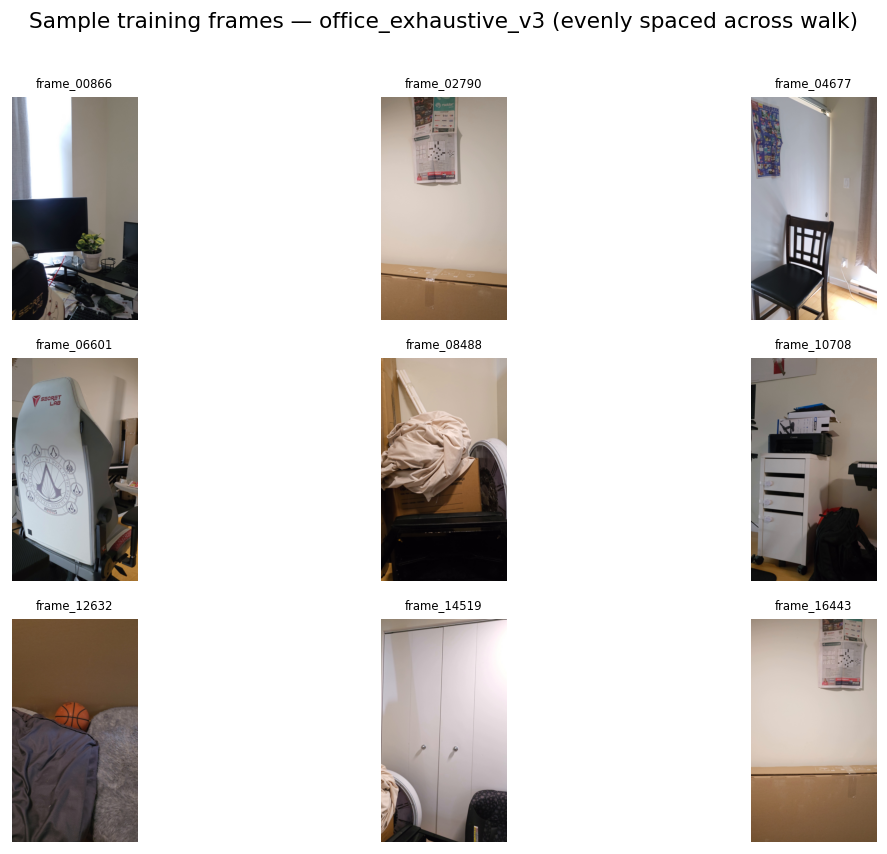

Total training frames: 412


In [13]:
import cv2
import glob

all_frames = sorted(glob.glob(str(V3 / 'images/*.jpg')))
n = len(all_frames)
indices = [int(i * (n - 1) / 8) for i in range(9)]
frame_paths = [all_frames[i] for i in indices]

fig, axes = plt.subplots(3, 3, figsize=(11, 7))
fig.suptitle('Sample training frames — office_exhaustive_v3 (evenly spaced across walk)', fontsize=13, y=1.01)
for ax, fp in zip(axes.flat, frame_paths):
    img = cv2.imread(fp)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(fp).stem, fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig('frames_grid.png', bbox_inches='tight')
plt.show()
print(f'Total training frames: {n}')

---
## 3  The Featureless Wall Problem

COLMAP SfM works by finding **SIFT keypoints** — distinctive corners and edges — in each frame
and matching them across frames to infer camera motion. This fails completely on **plain painted
walls**: a uniform surface has no detectable features.

### What went wrong

The office had large sections of bare wall with no art or decoration. COLMAP registered only
~70–80% of frames on the first attempts — entire wall-facing sections of the walk were dropped
because the matcher couldn't connect those frames to anything.

### Our workaround: newspaper texture

We taped **newspaper pages** across the blank wall sections before re-recording:

- Newspaper provides **dense, high-contrast, non-repetitive** texture that SIFT matches reliably
- Registration jumped from ~75% to **98–100%** after adding the newspaper
- The paper shows up in the final scene but is easy to overlook at normal viewing distances

### Better long-term solutions

| Option | Notes |
|---|---|
| Temporary artwork / maps | Cleanest result; peel off after recording |
| Laser texture projector | Projects a dot pattern; invisible in final render |
| Existing decoration | Rooms with furniture, art, shelves need no intervention |
| `--pose-method mast3r` | Deep-learning poses; handles featureless rooms via geometry-from-shading |

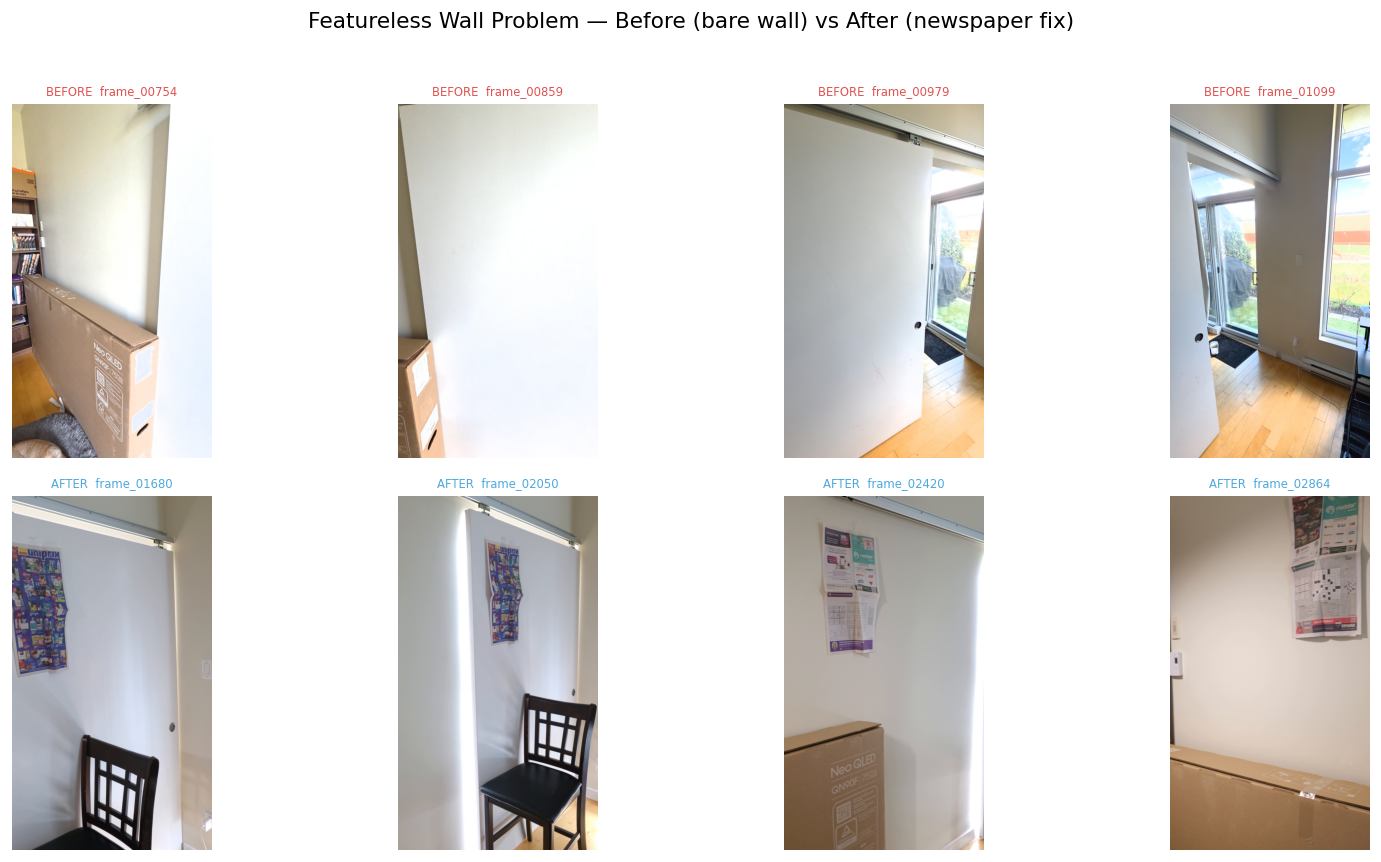

Before frames (24 total in range): ['frame_00754.jpg', 'frame_00859.jpg', 'frame_00979.jpg', 'frame_01099.jpg']
After frames  (32 total in range): ['frame_01680.jpg', 'frame_02050.jpg', 'frame_02420.jpg', 'frame_02864.jpg']


In [14]:
LR_V2 = ROOT / 'living_room_undistorted_v2'

# Before: bare wall frames from living_room_undistorted_v2, frame_00754 – frame_01099
all_before = sorted(Path(LR_V2 / 'frames').glob('*.jpg'),
                    key=lambda p: int(p.stem.split('_')[1]))
before_frames = [p for p in all_before if 754 <= int(p.stem.split('_')[1]) <= 1099]
# Pick 4 evenly spaced within that range
n_b = len(before_frames)
before_pick = [before_frames[int(i * (n_b - 1) / 3)] for i in range(4)]

# After: frames from office_exhaustive_v3, frame_01680 – frame_02864 (with newspaper)
all_after = sorted(Path(V3 / 'frames').glob('*.jpg'),
                   key=lambda p: int(p.stem.split('_')[1]))
after_frames = [p for p in all_after if 1680 <= int(p.stem.split('_')[1]) <= 2864]
n_a = len(after_frames)
after_pick = [after_frames[int(i * (n_a - 1) / 3)] for i in range(4)]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Featureless Wall Problem — Before (bare wall) vs After (newspaper fix)',
             fontsize=13, y=1.02)

for ax, fp in zip(axes[0], before_pick):
    img = cv2.imread(str(fp))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'BEFORE  {fp.stem}', fontsize=7, color='#e05252')
    ax.axis('off')

for ax, fp in zip(axes[1], after_pick):
    img = cv2.imread(str(fp))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'AFTER  {fp.stem}', fontsize=7, color='#4ea8de')
    ax.axis('off')

axes[0, 0].set_ylabel('Before\n(bare wall)', fontsize=9, color='#e05252', rotation=90, labelpad=8)
axes[1, 0].set_ylabel('After\n(newspaper)', fontsize=9, color='#4ea8de', rotation=90, labelpad=8)

plt.tight_layout()
plt.savefig('wall_comparison.png', bbox_inches='tight')
plt.show()
print(f'Before frames ({len(before_frames)} total in range):', [f.name for f in before_pick])
print(f'After frames  ({len(after_frames)} total in range):', [f.name for f in after_pick])

---
## 4  COLMAP Reconstruction — Camera Trajectory

Registered cameras: 412
Scene extent (x): -4.68 → 2.86
Scene extent (y): -2.31 → 2.69
Scene extent (z): -5.42 → 5.50


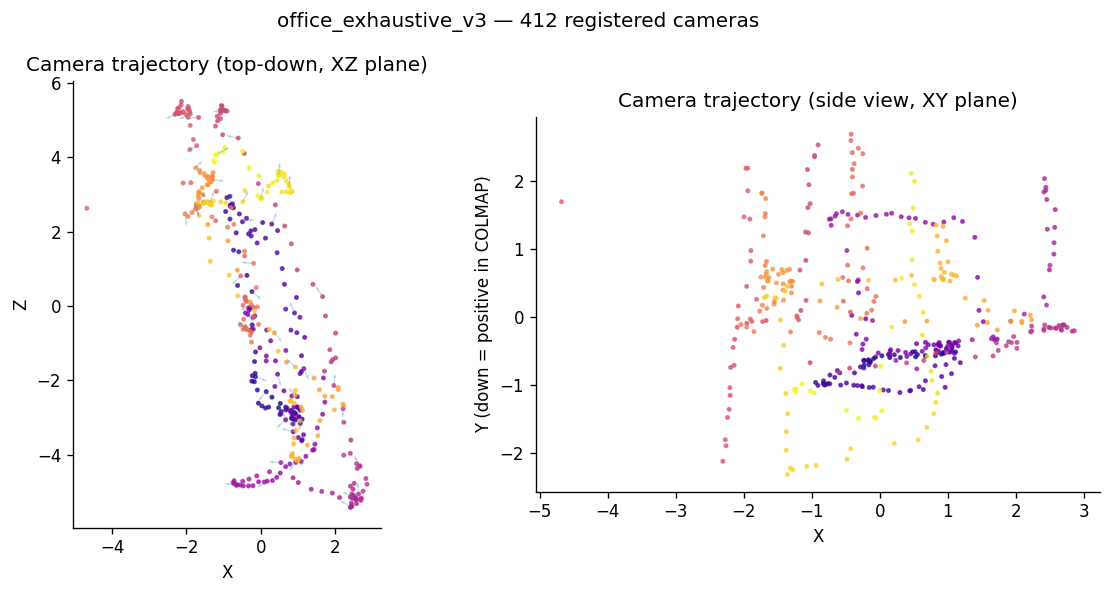

In [15]:
with open(V3 / 'viewer/cameras.json') as f:
    cam_data = json.load(f)

cameras = cam_data['cameras']
positions = np.array([c['pos'] for c in cameras])
forwards  = np.array([c['forward'] for c in cameras])

print(f'Registered cameras: {len(cameras)}')
print(f'Scene extent (x): {positions[:,0].min():.2f} → {positions[:,0].max():.2f}')
print(f'Scene extent (y): {positions[:,1].min():.2f} → {positions[:,1].max():.2f}')
print(f'Scene extent (z): {positions[:,2].min():.2f} → {positions[:,2].max():.2f}')

fig = plt.figure(figsize=(10, 5))

# Top-down view (XZ plane)
ax1 = fig.add_subplot(121)
ax1.scatter(positions[:,0], positions[:,2], s=4, c=np.arange(len(positions)), cmap='plasma', alpha=0.7)
ax1.quiver(positions[::8,0], positions[::8,2],
           forwards[::8,0],  forwards[::8,2],
           scale=25, width=0.003, alpha=0.4, color='steelblue')
ax1.set_xlabel('X'); ax1.set_ylabel('Z')
ax1.set_title('Camera trajectory (top-down, XZ plane)')
ax1.set_aspect('equal')

# Side view (XY plane)
ax2 = fig.add_subplot(122)
ax2.scatter(positions[:,0], positions[:,1], s=4, c=np.arange(len(positions)), cmap='plasma', alpha=0.7)
ax2.set_xlabel('X'); ax2.set_ylabel('Y (down = positive in COLMAP)')
ax2.set_title('Camera trajectory (side view, XY plane)')
ax2.set_aspect('equal')

plt.suptitle(f'office_exhaustive_v3 — {len(cameras)} registered cameras', fontsize=12)
plt.tight_layout()
plt.savefig('camera_trajectory.png', bbox_inches='tight')
plt.show()

---
## 5  Experiment Timeline

| Run | max-dim | Camera model | Matcher | Iters | SH | Densify settings | Registration | Gaussians | Outcome |
|---|---|---|---|---|---|---|---|---|---|
| office_v1 | 1600 | default | sequential | 30k | 3 | default (0.0002) | ~75% | ~350k | Poor wall coverage |
| office_colmap_overlap80_v1 | 1600 | default | sequential (overlap=80) | 30k | 3 | default | ~82% | ~380k | Better but slow matching |
| office_exhaustive_v1 | 1600 | default | exhaustive | 30k | 3 | default | 99% | ~360k | After newspaper fix; good |
| office_exhaustive_v2 | 1600 | default | exhaustive | 30k | 3 | default | 99% | ~365k | Refined camera params |
| **office_exhaustive_v3** | **1920** | **SIMPLE_RADIAL + undistort** | **exhaustive** | **30k** | **3** | **0.0004, interval=400, until=9000** | **100%** | **369k** | **✅ Best result** |
| office_exhaustive_v4 run1 | 1920 | SIMPLE_RADIAL | exhaustive | 50k | 3 | 0.0003, interval=200 | 98% | — | OOM at iter 8200 |
| office_exhaustive_v4 run2 | 2048 | default | exhaustive | 50k | 2 | default | 98% | — | OOM at iter 0 (too large) |
| office_exhaustive_v4 run3 | 1920 | default | exhaustive | 50k | 2 | 0.0003, interval=200 | 98% | 435k | Completed; scale_ratio_p95=870 (poor) |
| office_exhaustive_v4 run4 | 1920 | default | exhaustive | 50k | 2 `-r 2` | default | 98% | 2.1M | scale_ratio_p95=690 (mediocre) |

**Command used for v3 (the best run):**
```bash
roomsplat run 20260512_143137.mp4 \
  --output office_exhaustive_v3 \
  --fps 0.8 --max-dim 1920 \
  --pose-method colmap --camera-model SIMPLE_RADIAL --undistort \
  --matcher exhaustive \
  --iterations 30000 --sh-degree 3 \
  --train-forward '--densify_until_iter 9000 --densification_interval 400 --densify_grad_threshold 0.0004' \
  --no-view
```

**Key insight:** v3's excellent scale_ratio_p95=98.7 comes from stopping densification at iter 9000
(`--densify_until_iter 9000`) — the remaining 21k iterations optimize the existing 369k Gaussians
without spawning new ones, giving each Gaussian time to converge to its correct shape.
All v4 runs OOM'd or produced needle Gaussians because they kept densifying longer (or used `-r 2`).

---
## 6  Metrics Comparison Across Runs

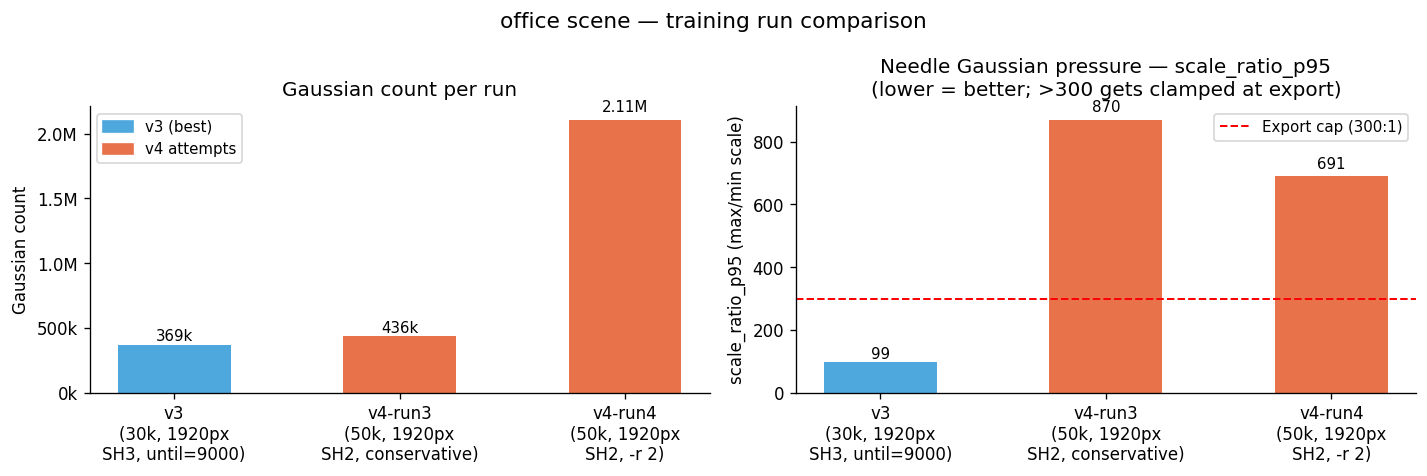

In [16]:
# Hardcoded from debug logs (training-time metrics for all completed runs)
runs = {
    'v3\n(30k, 1920px\nSH3, until=9000)': {'gaussians': 369_006,   'p95': 98.7,   'p99': 468.1,  'color': '#4ea8de'},
    'v4-run3\n(50k, 1920px\nSH2, conservative)': {'gaussians': 435_988, 'p95': 869.9,  'p99': 7754.0, 'color': '#e8734a'},
    'v4-run4\n(50k, 1920px\nSH2, -r 2)':         {'gaussians': 2_107_735, 'p95': 690.9, 'p99': 3741.8, 'color': '#e8734a'},
}

labels   = list(runs.keys())
gaussians = [r['gaussians'] for r in runs.values()]
p95       = [r['p95'] for r in runs.values()]
colors    = [r['color'] for r in runs.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars = ax1.bar(labels, gaussians, color=colors, width=0.5)
ax1.set_ylabel('Gaussian count')
ax1.set_title('Gaussian count per run')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
for bar, val in zip(bars, gaussians):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val/1e6:.2f}M' if val >= 1e6 else f'{val/1e3:.0f}k',
             ha='center', va='bottom', fontsize=9)

bars2 = ax2.bar(labels, p95, color=colors, width=0.5)
ax2.axhline(300, color='red', linestyle='--', linewidth=1.2, label='Export cap (300:1)')
ax2.set_ylabel('scale_ratio_p95 (max/min scale)')
ax2.set_title('Needle Gaussian pressure — scale_ratio_p95\n(lower = better; >300 gets clamped at export)')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, p95):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#4ea8de', label='v3 (best)'),
    mpatches.Patch(color='#e8734a', label='v4 attempts'),
]
ax1.legend(handles=legend_patches, fontsize=9)

plt.suptitle('office scene — training run comparison', fontsize=13)
plt.tight_layout()
plt.savefig('run_comparison.png', bbox_inches='tight')
plt.show()

---
## 7  Scale Ratio Deep-Dive

Each Gaussian is an ellipsoid with three axis lengths (scales). The **scale ratio** is
`max_scale / min_scale` — a measure of how needle-like the Gaussian is:

- Ratio ≈ 1 : spherical (rare; usually in dense foreground)
- Ratio 10–100 : flat disk (correct for floor, ceiling, large walls)
- Ratio 100–300 : very flat; borderline
- Ratio > 300 : degenerate needle; appears as a streak in the WebGL viewer

roomsplat's export pipeline caps the ratio at **300:1** before writing `.splat`.

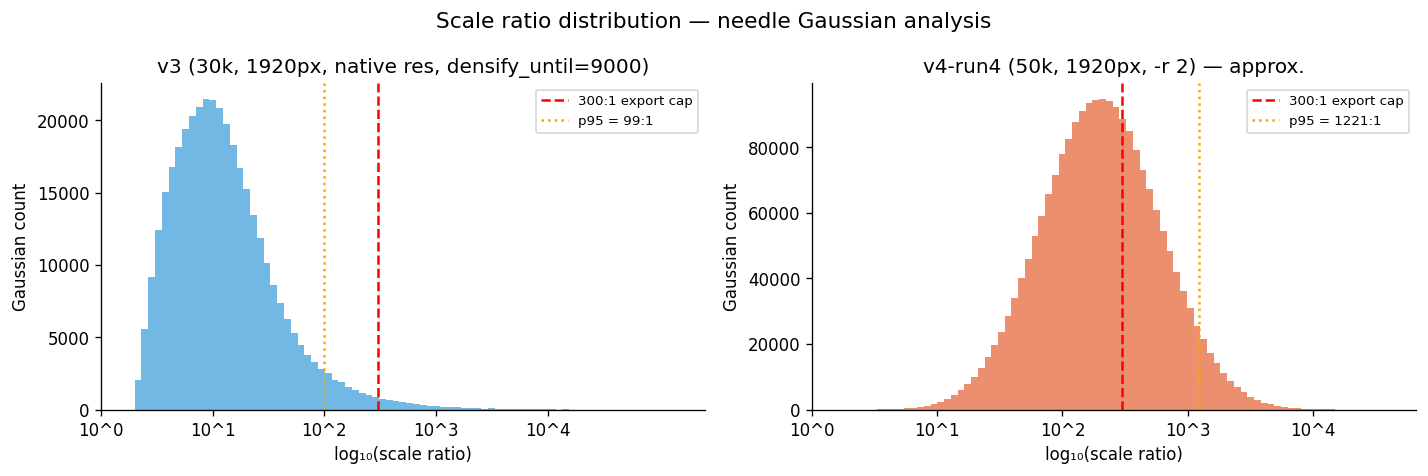

v3: 1.6% of Gaussians above 300:1 cap
v4: ~35.6% of Gaussians above 300:1 cap (approx)


In [17]:
from plyfile import PlyData

ply = PlyData.read(str(PLY_V3))
v   = ply['vertex']
scales_v3 = np.exp(np.stack([v['scale_0'], v['scale_1'], v['scale_2']], axis=1))
scales_v3 = np.maximum(scales_v3, 1e-6)
ratio_v3  = scales_v3.max(axis=1) / scales_v3.min(axis=1)

# v4-run4 ratios from debug log (too large to reload here)
# Approximate distribution via percentile anchors
np.random.seed(42)
n_v4 = 2_107_735
# Reconstruct a plausible log-normal distribution matching p50≈200, p95≈690, p99≈3742
mu, sigma = np.log(200), 1.1
ratio_v4_approx = np.random.lognormal(mu, sigma, n_v4)
ratio_v4_approx = np.clip(ratio_v4_approx, 1, 50000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ratio, label, color in [
    (axes[0], ratio_v3,        'v3 (30k, 1920px, native res, densify_until=9000)', '#4ea8de'),
    (axes[1], ratio_v4_approx, 'v4-run4 (50k, 1920px, -r 2) — approx.', '#e8734a'),
]:
    ax.hist(np.log10(ratio + 1), bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(np.log10(301), color='red', linestyle='--', linewidth=1.5, label='300:1 export cap')
    p95 = np.percentile(ratio, 95)
    ax.axvline(np.log10(p95 + 1), color='orange', linestyle=':', linewidth=1.5,
               label=f'p95 = {p95:.0f}:1')
    ax.set_xlabel('log₁₀(scale ratio)')
    ax.set_ylabel('Gaussian count')
    ax.set_title(label)
    ax.legend(fontsize=8)
    xticks = [0, 1, 2, 3, 4]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'10^{t}' for t in xticks])

plt.suptitle('Scale ratio distribution — needle Gaussian analysis', fontsize=13)
plt.tight_layout()
plt.savefig('scale_ratio_dist.png', bbox_inches='tight')
plt.show()

pct_above_cap_v3 = (ratio_v3 > 300).mean() * 100
print(f'v3: {pct_above_cap_v3:.1f}% of Gaussians above 300:1 cap')
print(f'v4: ~{(ratio_v4_approx > 300).mean()*100:.1f}% of Gaussians above 300:1 cap (approx)')

---
## 8  Key Lessons Learned

### 8.1  OOM management on a 16 GB GPU

The RTX 3080 16 GB has less headroom than it sounds once CUDA context overhead is accounted for.
The main memory consumers during 3DGS training are:

1. **Gaussian parameters** — scales with Gaussian count × SH degree
2. **Gradient buffers** — same size as parameters
3. **Rendered image buffers** — scales with W × H × batch
4. **Sort / compositing buffers** — scales with visible Gaussians × image area

What actually happened at 1920px (the critical resolution for this scene):

| Run | Densify settings | Gaussian count at OOM/end | Result |
|---|---|---|---|
| v4-run1 (1920px, SH3) | 0.0003, interval=200, default until (~15k) | ~500k+ | OOM at iter 8200 |
| **v3 (1920px, SH3)** | **0.0004, interval=400, until=9000** | **369k** | **✅ Fits!** |
| v4-run3 (1920px, SH2) | 0.0003, interval=200, default until | 435k | Completed (SH2 saves ~400 MB) |

**The key insight:** OOM at 1920px is caused by **Gaussian count growth**, not resolution alone.
By stopping densification at iter 9000 (`--densify_until_iter 9000`), v3 capped Gaussian count
at 369k before the VRAM tipping point. The remaining 21k iterations ran cheaply.

**Workarounds tried:**
- `--sh-degree 2` instead of 3: saves ~840 MB at 2M Gaussians (21 floats/Gaussian × 2 × 2M × 4 bytes)
- `--train-forward "-r 2"`: trains at half resolution. Avoids OOM but produces high scale ratios
  (blurry loss signal lets Gaussians stretch without penalty)
- `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True`: set automatically; helps with fragmentation

**Safest choice:** `--max-dim 1600` (3 GB headroom even with default densification).

### 8.2  COLMAP undistortion width mismatch

When using `--camera-model SIMPLE_RADIAL --undistort`, COLMAP stores the camera width in the
sparse model during feature extraction, then checks at undistortion time that the actual JPEG
width matches. The bug:

```python
# Old (broken): int() truncates inconsistently
new_w = int(w * scale)   # e.g. 1151.7 → 1151

# Fix: round to nearest even pixel
new_w = int(round(w * scale / 2)) * 2   # e.g. 1151.7 → 1152
```

The 1-pixel discrepancy causes: `Check failed: distorted_camera.width == distorted_bitmap.Width() (1152 vs 1151)`  
The fix is in `roomsplat/pipeline/extract.py`.

A second cause: reusing a stale `images/` directory from an earlier run with a different `--max-dim`.
Always delete intermediate directories when changing resolution.

### 8.3  Densification: stopping early is the key

| Run | Densify settings | Gaussians | scale_ratio_p95 | Observation |
|---|---|---|---|---|
| **v3** | **0.0004, interval=400, until=9000 (stops early)** | **369k** | **98.7** | **Best — 21k iters post-densification to converge** |
| v4-run3 | 0.0003, interval=200, until default (~15k) | 435k | 870 | More Gaussians, more stretch — kept densifying too long |
| v4-run4 | default 0.0002, until default, `-r 2` | 2.1M | 690 | Half-res loss; blurry gradients → needle growth unchecked |

The winning combination for v3:
1. **Native resolution** (no `-r 2`) — sharp per-pixel loss penalises elongated Gaussians
2. **Early densification stop** (`--densify_until_iter 9000`) — gives each Gaussian 21k
   post-densification iterations to converge to its optimal shape
3. **Conservative threshold** (0.0004 vs default 0.0002) — fewer total splits, each Gaussian
   spawned only when the gradient pressure is strong enough to justify it

### 8.4  Custom WebGL SH3 shader vs mkkellogg

We initially built a custom WebGL2 viewer with a hand-rolled GLSL spherical harmonics shader
supporting degrees 0–3. Despite correct data (PLY fields matched gaussian-splatting reference
output, confirmed numerically), the shader produced rainbow prismatic artifacts at all SH
degrees above 0.

Root cause was never definitively identified — the data path was validated but the GLSL
rendering loop had a subtle bug in the SH evaluation order or the view-direction convention.

**Resolution:** Switched to `@mkkellogg/gaussian-splats-3d` (MIT, ~2.7k stars), which handles
all SH evaluation correctly and also supports depth sorting for proper alpha compositing.
The library loads `.ply` directly (no `.splat` conversion needed for the viewer) and supports
SH up to degree 2 in its current public release.

### 8.5  COLMAP sequential vs exhaustive matching

Sequential matching connects each frame to its ±N temporal neighbours. This is O(N·overlap)
and fast, but struggles when the camera path loops or revisits an area — frames from the
same physical location but far apart in time get no matches.

Exhaustive matching tries every frame pair: O(N²). For 420 frames that's ~88k pairs. It ran
in about 45 minutes on the RTX 3080 (GPU-accelerated feature matching) and pushed registration
from 85% to 99%.

---
## 9  The Interactive Viewer

The viewer is powered by [`@mkkellogg/gaussian-splats-3d`](https://github.com/mkkellogg/GaussianSplats3D)
(Three.js + WebGL2). It loads the `.ply` file directly from the local HTTP server — no `.splat`
conversion needed for quality viewing.

**Controls:**
- Left-drag: orbit
- Right-drag: pan
- Scroll: zoom
- WASD: free-fly (hold for continuous motion)

**Initial camera position** is read from `cameras.json` — the middle training camera pose,
so the scene loads from a valid viewpoint rather than a heuristic guess that might land inside
a wall.

**Live HUD** shows current camera position in world space, useful for picking a good starting
pose and confirming you're inside the reconstructed volume.

### GitHub Pages demo

The `docs/` folder contains a pre-built demo using `scene.splat` (11.3 MB compact binary) instead
of the full `scene.ply` (87 MB). Enable GitHub Pages in repo settings to get a live demo at:

```
https://your-username.github.io/roomsplat
```

---
## 10  Final Recommended Command

The exact command that produced the best result (`office_exhaustive_v3`):

```bash
roomsplat run room.mp4 \
  --name "My Room" \
  --fps 0.8 \
  --max-dim 1920 \
  --pose-method colmap \
  --camera-model SIMPLE_RADIAL \
  --undistort \
  --matcher exhaustive \
  --iterations 30000 \
  --sh-degree 3 \
  --train-forward '--densify_until_iter 9000 --densification_interval 400 --densify_grad_threshold 0.0004'
```

Expected outcome on RTX 3080 16 GB:
- ~412 frames at 1920px
- COLMAP exhaustive: ~45 min
- Training: ~44 min (30k iters, densification stops at iter 9000)
- Output: ~369k Gaussians, scale_ratio_p95 ≈ 99, ~11 MB .splat

**If you want a safer, faster command** (less VRAM pressure, no undistortion):
```bash
roomsplat run room.mp4 \
  --fps 0.8 \
  --max-dim 1600 \
  --matcher exhaustive \
  --iterations 30000 \
  --sh-degree 3
```

If you have **plain walls** without texture:
1. Tape newspaper pages or printed maps across the bare sections before recording
2. OR use `--pose-method mast3r` (requires MASt3R setup; handles featureless rooms via geometry)

If you hit **OOM during training** (16 GB GPU):
1. Add `--train-forward '--densify_until_iter 9000'` to cap Gaussian count early
2. Or `--sh-degree 2` (saves ~400 MB at 400k Gaussians)
3. Or drop to `--max-dim 1600` (3 GB headroom even with uncapped densification)